In [1]:
import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt
import japanize_matplotlib

In [2]:
# 画像パスの設定
INPUT_IMG = '/workspace/output/IMG-VV-STRIX1-20221212T192710Z-SMGRD_clip.tif'

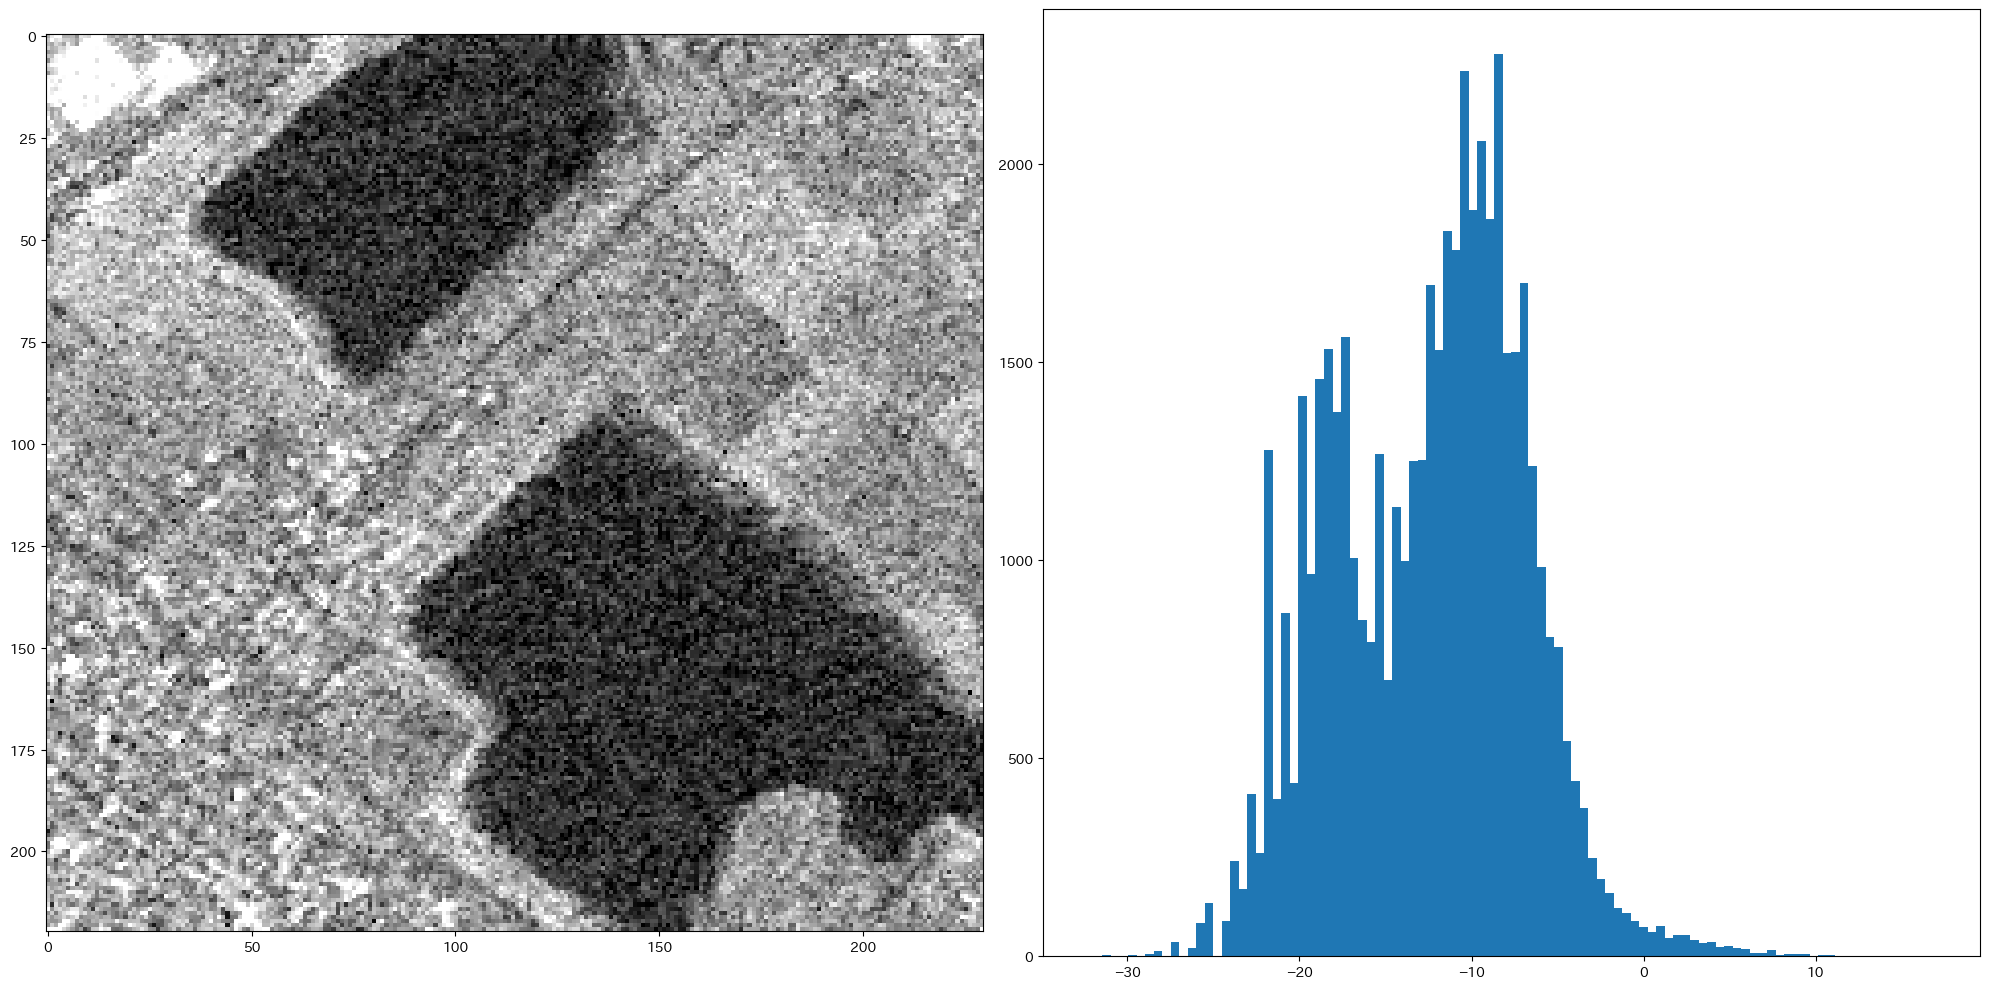

In [3]:
# 画像の読み込みと可視化
with rio.open(INPUT_IMG) as src:
    img = src.read(1)
    img_dB = 10 * np.log10(img)

p2, p98 = np.percentile(img_dB, [2, 98])

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(img_dB, cmap='gray', vmin=p2, vmax=p98)
plt.subplot(1, 2, 2)
plt.hist(img_dB.flatten(), bins=100)
plt.tight_layout()
plt.show()

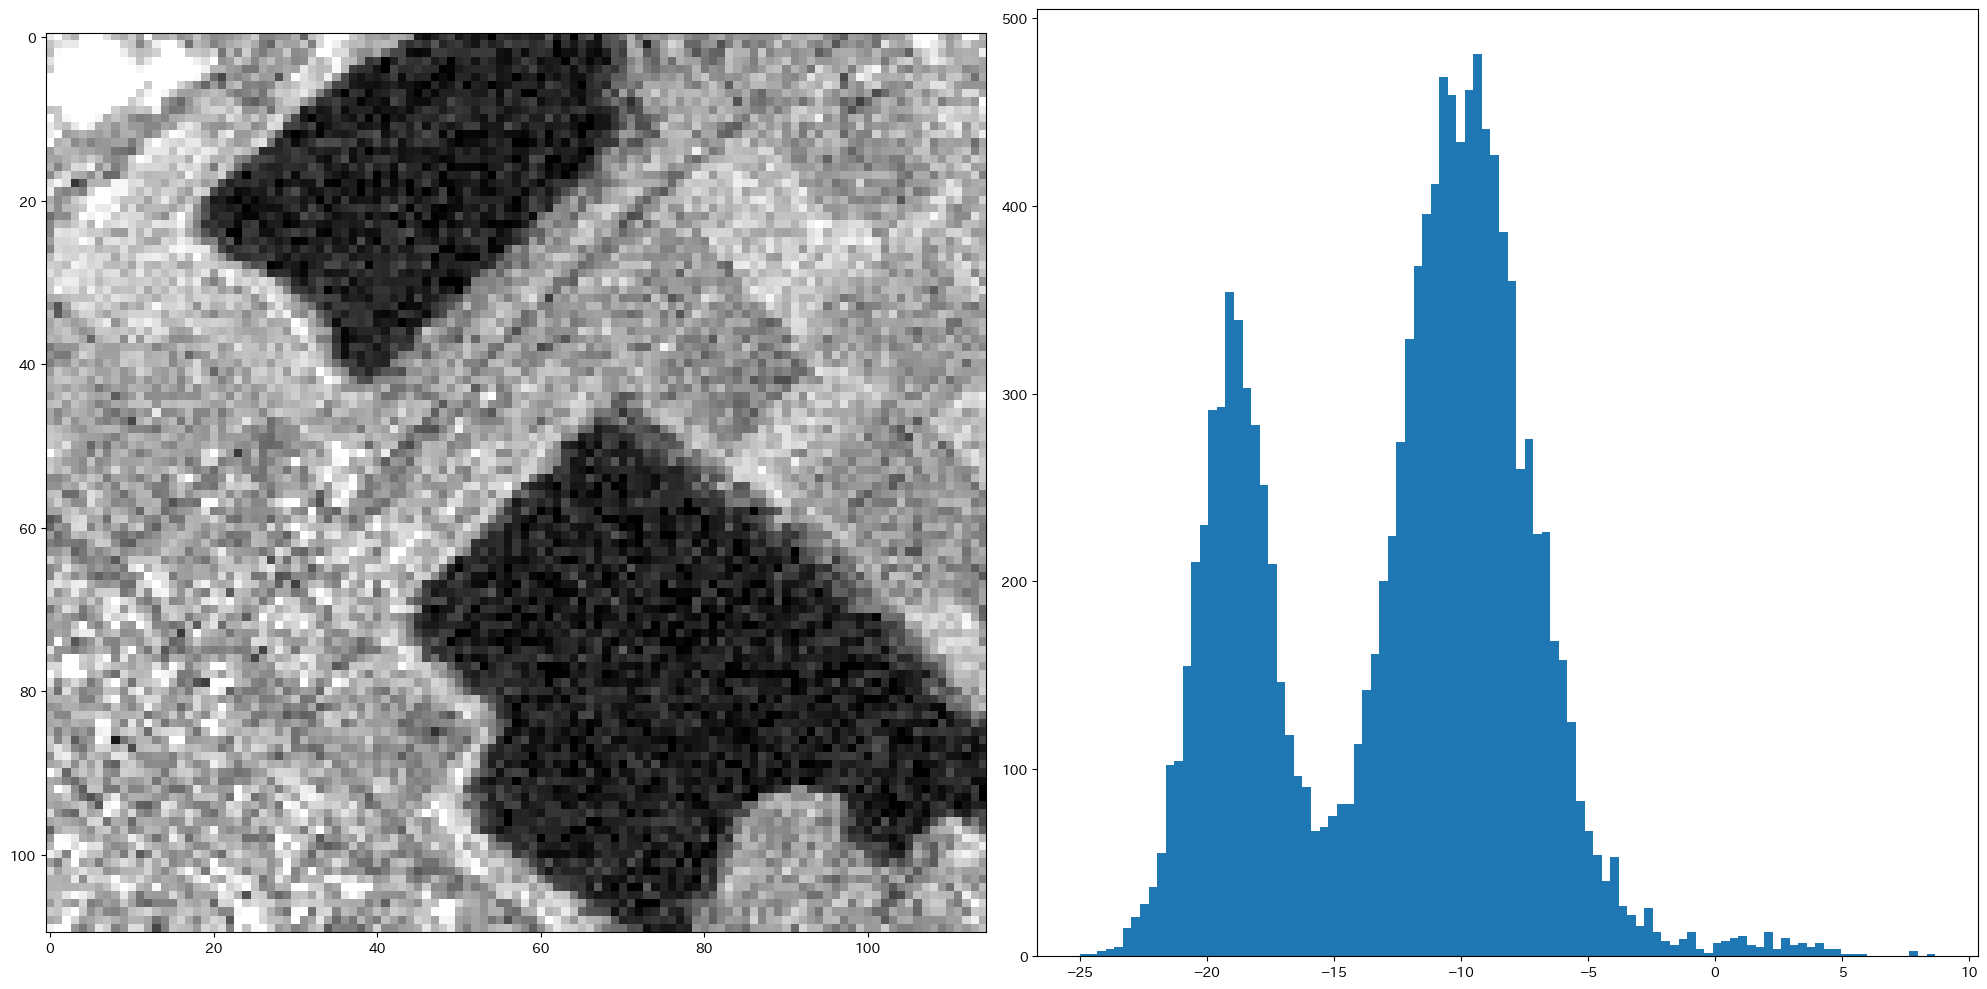

In [4]:
# マルチルック処理用の画像サイズとピクセル数を設定
reshaped_data = img_dB.reshape((img_dB.shape[0] // 2, 2, img_dB.shape[1] // 2, 2))

# マルチルック処理の実施
multilooked_data = reshaped_data.mean(axis=(1, 3))

# マルチルック処理後の画像とヒストグラムを可視化
p2, p98 = np.percentile(multilooked_data, [2, 98])

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(multilooked_data, cmap='gray', vmin=p2, vmax=p98)
plt.subplot(1, 2, 2)
plt.hist(multilooked_data.flatten(), bins=100)
plt.tight_layout()
plt.show()

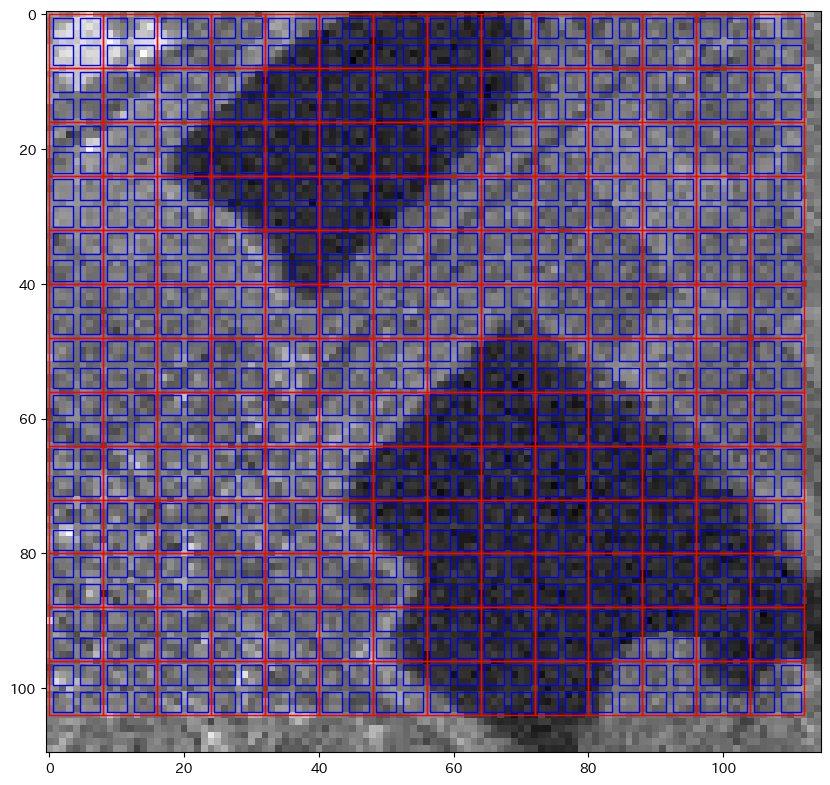

In [6]:
# 2段階の四文木分割を実施
def create_tiles(image, tile_size):

    # 画像のサイズとタイルのサイズから縦横のタイル数を設定
    height, width = image.shape
    n_rows = int(np.ceil(height / tile_size))
    n_cols = int(np.ceil(width / tile_size))

    # L+とL-のタイルを生成
    l_plus = []
    l_plus_positions = []
    l_minus = []
    l_minus_positions = []
    for i in range(n_rows):
        for j in range(n_cols):
            y_start = i * tile_size
            y_end = min((i + 1) * tile_size, height)
            x_start = j * tile_size
            x_end = min((j + 1) * tile_size, width)
            l_plus_tile = image[y_start:y_end, x_start:x_end]

            # 正方形のタイルのみ保存
            if l_plus_tile.shape[0] == l_plus_tile.shape[1]: 
                l_plus.append(l_plus_tile)
                l_plus_positions.append((y_start, y_end, x_start, x_end))

                l_minus_tiles = []
                l_minus_tiles_positions = []
                l_plus_height, l_plus_width = l_plus_tile.shape
                half_tile_size = int(np.ceil(tile_size / 2))

                for y in range(0, l_plus_height, half_tile_size):
                    for x in range(0, l_plus_width, half_tile_size):
                        y_end = min(y + half_tile_size, l_plus_height)
                        x_end = min(x + half_tile_size, l_plus_width)
                        l_minus_tile = l_plus_tile[y:y_end, x:x_end]
                        l_minus_tiles.append(l_minus_tile)
                        l_minus_tiles_positions.append((y_start + y, y_start + y_end, x_start + x, x_start + x_end))
                
                l_minus.append(l_minus_tiles)
                l_minus_positions.append(l_minus_tiles_positions)

    return l_plus, l_plus_positions, l_minus, l_minus_positions

# 2段階の四文木分割の結果を可視化
def tile_visualization(image, l_plus_positions, l_minus_positions):
    fig, ax = plt.subplots(figsize=(10, 10))

    ax.imshow(image, cmap='gray')

    # L+のタイル群を可視化
    for i in range(len(l_plus_positions)):
        y_start, y_end, x_start, x_end = l_plus_positions[i]
        rect = plt.Rectangle((x_start, y_start), x_end-x_start, y_end-y_start, edgecolor='red', facecolor='none', linewidth=1)
        ax.add_patch(rect)
    
    # L-のタイル群を可視化
    for i in range(len(l_minus_positions)):
        for j in range(len(l_minus_positions[i])):
            y_start, y_end, x_start, x_end = l_minus_positions[i][j]
            rect = plt.Rectangle((x_start+0.5, y_start+0.5), x_end-x_start-1, y_end-y_start-1, edgecolor='blue', facecolor='none', linewidth=1)
            ax.add_patch(rect)

    plt.show()

# 2段階の四文木分割の実行
l_plus, l_plus_positions, l_minus, l_minus_positions = create_tiles(multilooked_data, tile_size=8)
tile_visualization(multilooked_data, l_plus_positions, l_minus_positions)

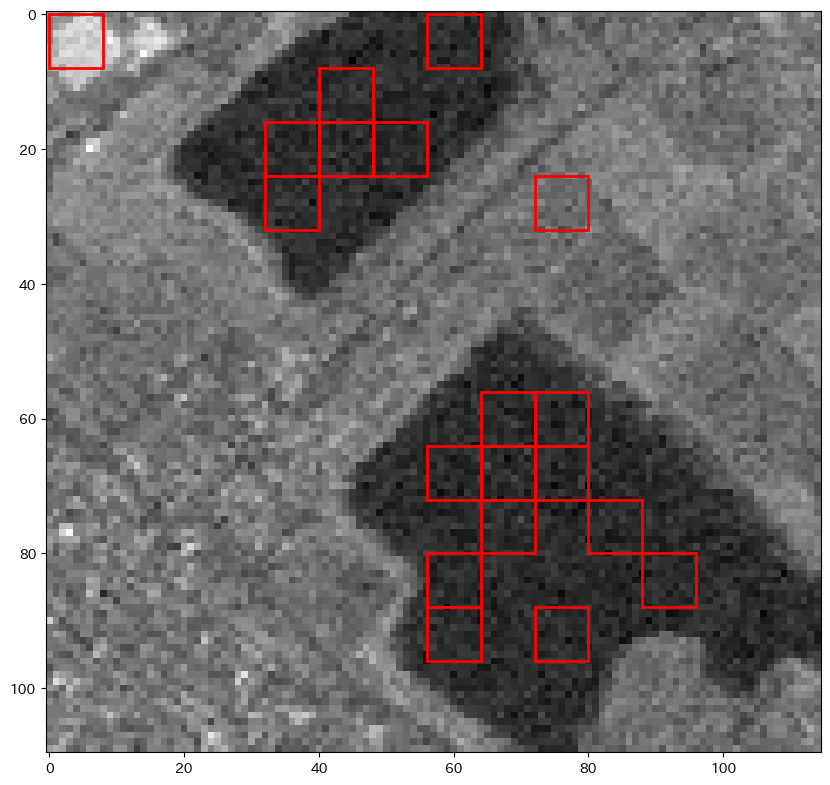

In [7]:
# L+タイルとL-タイルの統計情報から変動係数を算出
def calculate_coefficient_of_variation(l_plus, l_minus):
    coefficients_of_variation = []

    for i, l_plus_tile in enumerate(l_plus):
        l_minus_tiles = l_minus[i]
        l_minus_means = [np.mean(tile) for tile in l_minus_tiles]
        mean_std = np.std(l_minus_means)
        l_plus_mean = np.mean(l_plus_tile)
        coefficient_of_variation = mean_std / l_plus_mean
        coefficients_of_variation.append(coefficient_of_variation)

    return coefficients_of_variation

# 変動係数のリストから指定したパーセンタイルを超えるインデックスと値を抽出
def extract_top_percentile(coefficients_of_variation, percentile):
    threshold = np.percentile(coefficients_of_variation, percentile)
    
    top_coefficients = []
    for i, cv in enumerate(coefficients_of_variation):
        if cv > threshold:
            top_coefficients.append((i, cv))

    return top_coefficients

# 変動係数を基に抽出したタイルを可視化
def visualize_top_tiles(image, l_plus_positions, top_coefficients):
    fig, ax = plt.subplots(figsize=(10, 10))

    ax.imshow(image, cmap='gray')

    for i, cv in top_coefficients:
        y_start, y_end, x_start, x_end = l_plus_positions[i]
        rect = plt.Rectangle((x_start, y_start), x_end - x_start, y_end - y_start, edgecolor='red', facecolor='none', linewidth=2)
        ax.add_patch(rect)

    plt.show()

# 上記の関数を実行
coefficients_of_variation = calculate_coefficient_of_variation(l_plus, l_minus)
top_coefficients = extract_top_percentile(coefficients_of_variation, percentile=90)
visualize_top_tiles(multilooked_data, l_plus_positions, top_coefficients)

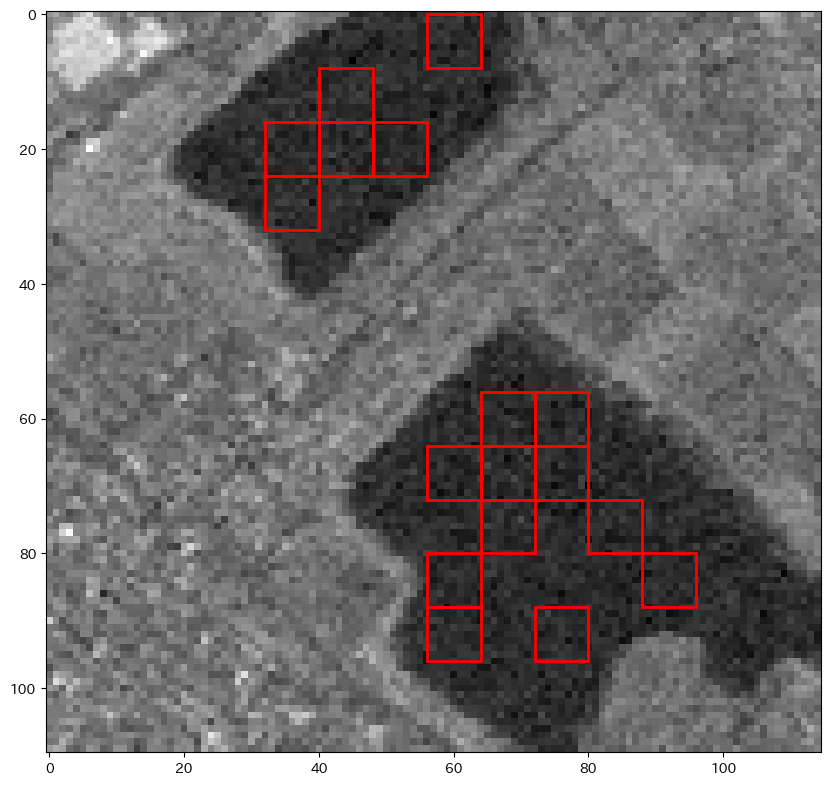

In [9]:
# 全体のL+タイルの平均値よりも低い平均値を持つL+タイルを抽出
def check_and_return_l_plus_below_average(l_plus, top_coefficients):
    all_l_plus_means = [np.mean(tile) for tile in l_plus]
    average_of_all_l_plus = np.mean(all_l_plus_means)

    l_plus_below_average = []
    indices_below_average = []
    for i, _ in top_coefficients:
        top_l_plus_mean = np.mean(l_plus[i])
        if top_l_plus_mean < average_of_all_l_plus:
            l_plus_below_average.append(l_plus[i])
            indices_below_average.append(i)

    return l_plus_below_average, indices_below_average

# 指定されたL+タイルを可視化
def tile_visualization(image, l_plus_positions, indices_below_average):
    fig, ax = plt.subplots(figsize=(10, 10))

    ax.imshow(image, cmap='gray')

    for i in indices_below_average:
        y_start, y_end, x_start, x_end = l_plus_positions[i]
        rect = plt.Rectangle((x_start, y_start), x_end - x_start, y_end - y_start, edgecolor='red', facecolor='none', linewidth=2)
        ax.add_patch(rect)

    plt.show()

# 上記の関数を実行
l_plus_below_average, indices_below_average  = check_and_return_l_plus_below_average(l_plus, top_coefficients)
tile_visualization(multilooked_data, l_plus_positions, indices_below_average)

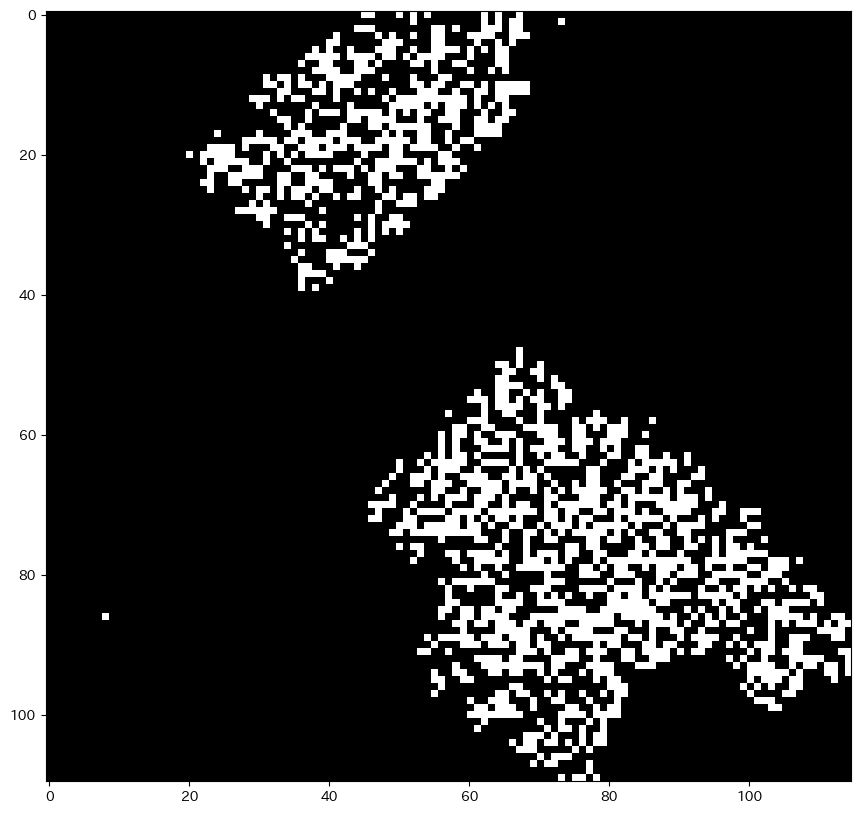

In [11]:
# 閾値の算出
threshold = np.mean(l_plus_below_average)

# 水域マスクの可視化
plt.figure(figsize=(20, 10))
plt.imshow(np.where(multilooked_data < threshold, 1, 0), cmap='gray')
plt.show()   